# Ocean Modelling: Exercise 11: The Advection Equation
numerical solution of the 1D advection problem:
$$ \frac{\partial T}{\partial t} =  -c \frac{\partial T}{\partial x}$$ 
using an explicit forward in time, centred in space scheme

$T(x,t)$ represents the evolution of temperature distribution along the estuary over time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## User Defined Parameters

In [2]:
# problem parameters
c=0.5       # Advection speed [m s-1]
dx=200      # X resolution [m]
dt=200      # time step [s]
t0=0.       # initial time
tmax=0.1    # duration of simulation [days]
xmax=10.0e3 # length of the basin [m]

# parameters of the initial temperature distribution
T0 = 15.        # baseline temperature [degC]
sigma = 2000.   # width at half amplitude [m]
A = 5.          # amplitude [degC]

## Initial Function and Grid Specifications
The initial shape of the temperature distribution is a Gaussian peak function.

In [3]:
# spatial shape of the temperature disturbance
def Gaussian(x):
    y = T0+A*np.exp(-(x/sigma)**2)
    return y

The resulting space-time grid depends on the parameters above.

In [4]:
# time axis
NT = int(np.floor(tmax*86400/dt))+1  # number of steps (starts from 0)
# x axis (centred at 0)
x = np.arange(-xmax,xmax,dx)
IM = len(x)             # number of grid points
T = np.zeros([IM,NT])     # the array holding the numerical solution 
print('Grid steps : ',IM)
print('Number of time steps : ',NT)
print('Timestep = ',dt,' s')
print('Max numerical speed DX/DT = ',dx/dt,' m/s')
print('Physical speed = ',c,' m/s')
print('Courant number = ',c*dt/dx)

Grid steps :  100
Number of time steps :  44
Timestep =  200  s
Max numerical speed DX/DT =  1.0  m/s
Physical speed =  0.5  m/s
Courant number =  0.5


## Numerical Solution
Note that this code stores the solution at all times in array T for educational purposes. This allows to plot the solution at the different time steps and see how it evolves.

*This method is very inefficient for any application because it uses a lot of memory. In modern computer codes only a few time records are hold in memory. The instantaneous solution is often temporarely stored for computing time averages and then discarded.*

This part of the code is the topic of some questions found in the lecture notes.

In [5]:
# compute the numerical solution using a time loop over the number of time steps
T[:,0] = Gaussian(x)    # initial condition

for n in range(NT-1):
    # Question 1
    T[0,n+1]  = T0
    T[-1,n+1] = T0
    # Question 2 and Question 3
    rhs = -c*(T[2:,n]-T[:-2,n])/(2.*dx) # L1
    T[1:-1,n+1] = T[1:-1,n] + rhs*dt    # L2

## Plot the Result Using a Matplotlib Animation
The animation below displays the evolution of the solution and compares it with the analytical solution.

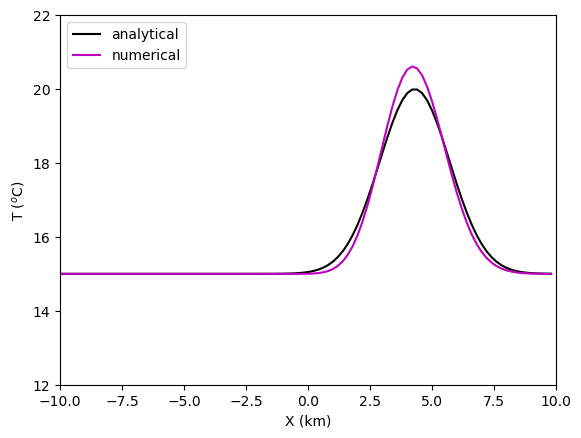

In [6]:
fig, ax = plt.subplots()
# set the axis limits
plt.axis([-xmax/1000, xmax/1000, T0-3, T0+7])
# first plot the initial conditions and set the line attributes
line, = ax.plot(x/1000., Gaussian(x),'k',label='analytical')
sol, = ax.plot(x/1000., T[:,0],'m',label='numerical')
ax.set_xlabel('X (km)')
ax.set_ylabel('T ($^o$C)')
plt.legend(loc='upper left')

def animate(i):
    t = t0 + i*dt
    line.set_ydata(Gaussian(x-c*t))  # update the analytical solution
    sol.set_ydata(T[:,i])  # update the numerical solution
    return line,sol,

# create the animation and loop (interval is in ms)
ani = animation.FuncAnimation(
    fig, animate, interval=dt, blit=True, frames=NT, repeat=True)

# To save the animation, use e.g.
# ani.save("movie.mp4")
# or
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

# display the animation as a javascript object embedded in the notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

The numerical solution of the advection problem is implemented in the notebook advection.ipynb. Familiarize yourself with the code and answer the following questions in a modified version of the notebook (make sure that you use headers to distinguish the various parts):
#### 1. Look for the comment #Question 1 in the code. What do you think the next two lines do? [hint: see slide fr:PDE-problems]
These 2 lines set the boudary conditions at each timestep. T[0, n+1] = T0 sets the temperature at the left boundary to the baseline value T0 at the new timestep (at the first grid point or value of x which is the miminum) and T[-1, n+1] = T0 sets the temperature at the right boundary to T0 at the new timestep (at the last grid point or value of x which is the maximum). 

#### 2. Look for #Question 2 in the code. Which component of the numerical scheme is implemented in line #L1? What does line #L2 do?
L1 computes the spatial derivative of the advection (the RHS of the advection equation). This uses a centred difference which means that in order to calculate the derivative at a point (i), the points on either side (i+1 and i-1) need to be known and used. L2 advances the solution forward in time using the Euler Forward (Explicit) scheme. 

#### 3. Look for #Question 3 in the code. Why the code does not perform the computation on all the elements of the array T, i.e. T[:,n]?
The centred different applied in L1 needs the points on either side of the point where the derivative is being calculated. This means that the derivative at the boundary points (the first and last points) cannot be caculated as they are missing a neighbouring point. The derivative can only be calculated at the interior points. 

#### 4. Analysis of the numerical solution. How different is the numerical solution from the expected moving perturbation? What is the possible reason?
The numerical solution underestimates the temperature along the boundaries and overestimates the temperature in the interior (the numerical curve is lower than the analytical curve at its tails but it has a higher peak). With space, the anayltical solution does not change its shape or peak temperature but the numerical solution grows taller and becomes narrower. The numerical solution is also travelling at a slightly slower speed than the analytical solution. This is beacuse the numerical solution is unconditionally unstable which means that it will produce growing errors. In order for the analytical solution (Gaussian) to be reproduced, a different scheme (other than the Euler Forward (Explicit)) that is stable must be used. 

#### 5. The grid parameters determine the value of the Courant Number and hence the stability. The spatial and temporal steps are linked. More spatial resolution (smaller dx) means that dt must also decrease to maintain the same Courant Number. However, things are not so simple. The higher spatial resolution (which should theoretically increase the Courant Number) also enhance the capability to resolve the real gradients (see the previous slide to understand how C interacts with the difference between adjacent points). If you increase the Courant Number to 1 by halving dx, what does it happen? Now set dx = 500 m and dt = 100 s to get C = 0.1; what do you see and how would you interpret it?

Baseline  C=0.5                 dx=  200 m  dt=  200 s  C=0.50  NT=44
Halved dx  C=1.0                dx=  100 m  dt=  200 s  C=1.00  NT=44
dx=500, dt=100  C=0.1           dx=  500 m  dt=  100 s  C=0.10  NT=87


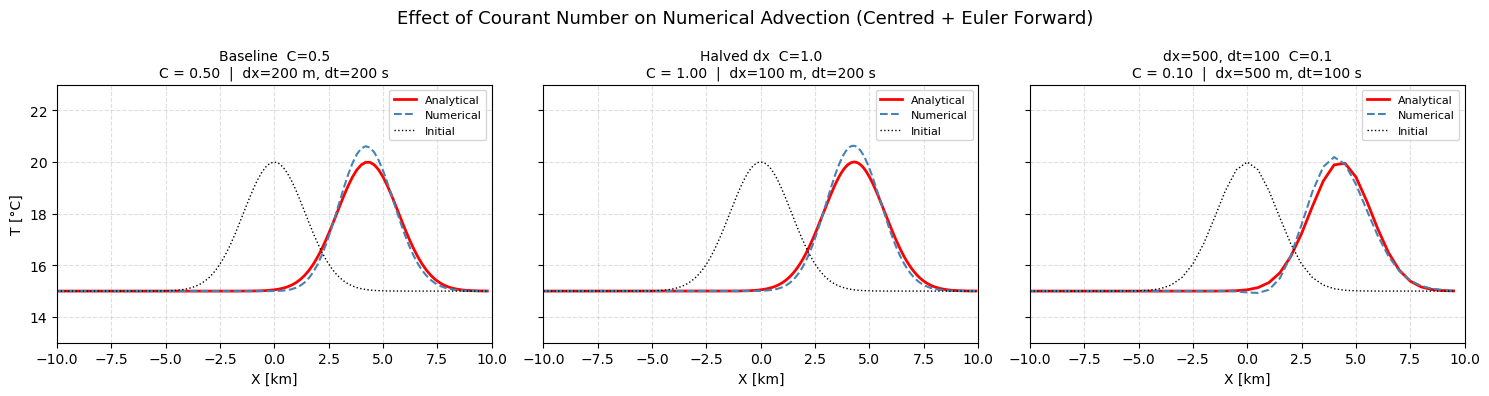

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# fixed parameters
c    = 0.5
t0   = 0.
tmax = 0.1
xmax = 10.0e3
T0   = 15
sigma = 2000
A    = 5

def Gaussian(x):
    return T0 + A * np.exp(-(x / sigma) ** 2)

def run(dx, dt, label):
    NT = int(np.floor(tmax * 86400 / dt)) + 1
    x  = np.arange(-xmax, xmax, dx)
    IM = len(x)
    t  = np.array([t0 + n * dt for n in range(NT)])

    T = np.zeros([IM, NT])
    T[:, 0] = Gaussian(x)

    for n in range(NT - 1):
        T[0,  n+1] = T0
        T[-1, n+1] = T0
        rhs = -c * (T[2:, n] - T[:-2, n]) / (2. * dx)
        T[1:-1, n+1] = T[1:-1, n] + rhs * dt

    # analytical solution at final time
    T_analytical = T0 + A * np.exp(-((x - c * t[-1]) / sigma) ** 2)

    courant = c * dt / dx
    print(f'{label:30s}  dx={dx:5.0f} m  dt={dt:5.0f} s  C={courant:.2f}  NT={NT}')
    return x, T[:, -1], T_analytical, courant

# three experiments
configs = [(200, 200, 'Baseline  C=0.5'), (100, 200, 'Halved dx  C=1.0'), (500, 100, 'dx=500, dt=100  C=0.1'),]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Effect of Courant Number on Numerical Advection (Centred + Euler Forward)', fontsize=13)

for ax, (dx, dt, label) in zip(axes, configs):
    x, T_num, T_ana, C = run(dx, dt, label)

    ax.plot(x / 1000, T_ana, 'r',         linewidth=2,   label='Analytical')
    ax.plot(x / 1000, T_num, 'steelblue', linewidth=1.5, label='Numerical', linestyle='--')
    ax.plot(x / 1000, Gaussian(x), 'k',  linewidth=1,   label='Initial', linestyle=':')

    ax.set_title(f'{label}\nC = {C:.2f}  |  dx={dx} m, dt={dt} s', fontsize=10)
    ax.set_xlabel('X [km]')
    ax.set_xlim(-xmax / 1000, xmax / 1000)
    ax.set_ylim(T0 - 2, T0 + A + 3)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

axes[0].set_ylabel('T [°C]')
plt.tight_layout()
plt.show()

#### 5. If you increase the Courant Number to 1 by halving dx, what does it happen? Now set dx = 500 m and dt = 100 s to get C = 0.1; what do you see and how would you interpret it?
- The numerical solution improves when dx is halved (Plot 2) as the grid resolution is finer and there are more points across the Gaussian pulse to resolve the shape better. The higher Courant Number with the higher resolution allows the solutions to be represented more accurately.
- When dx is made bigger (Plot 3), the grid resolution becomes coarser and the increase in timesteps due to the low Courant Number prevent the solution from growing smoothly which decreases the representation of the analytical and numerical solution. 

#### 6. The choice of the grid parameters also depend on the features that you want to resolve. Set the parameter σ = 1000 m (a steeper wave). What do you have to do to recover the same degree of accuracy of the previous solution? (note that it takes longer to generate the movie when you decrease the time step because NT increases and more frames are generated). Make another copy of the original notebook and double the current speed. How would you explain the result?

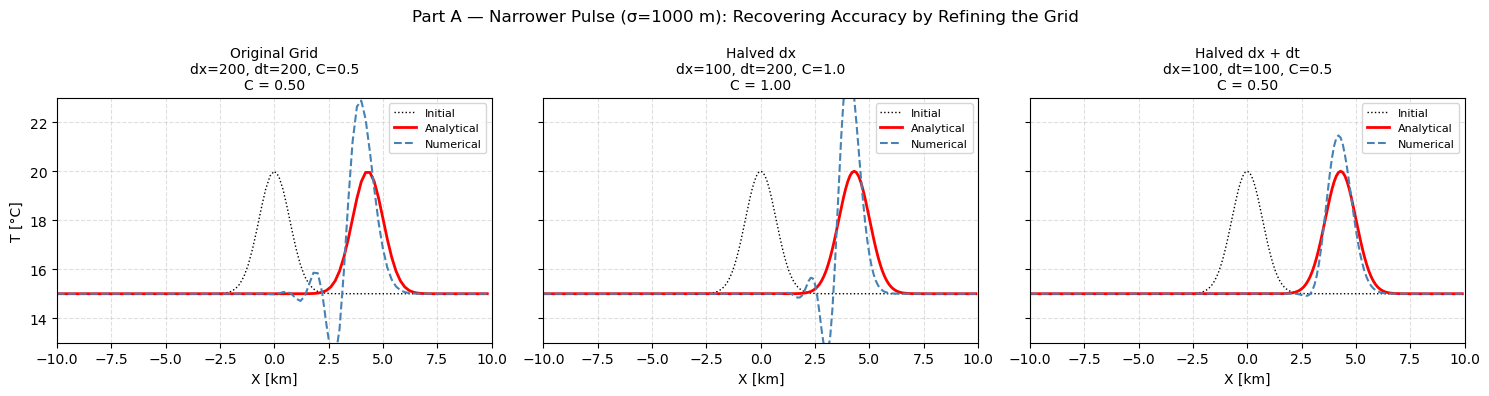

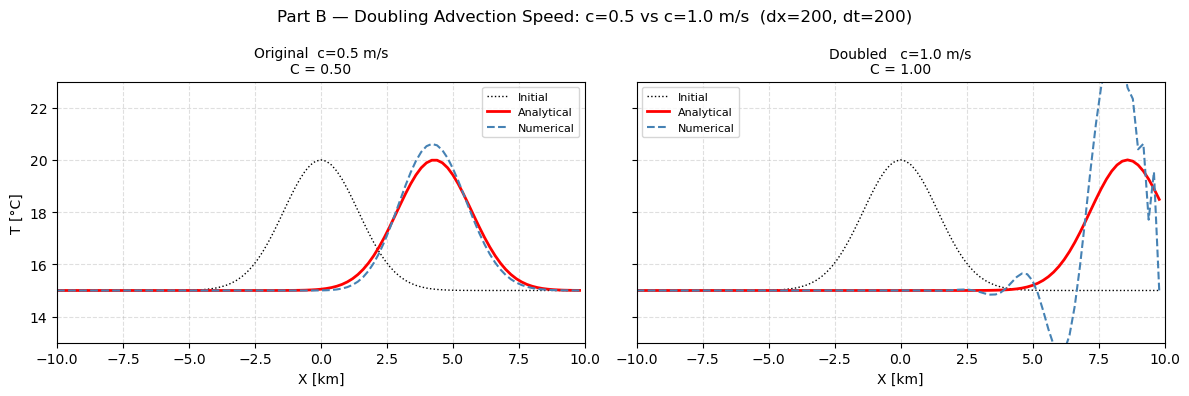

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# fixed parameters
c    = 0.5
t0   = 0.
tmax = 0.1
xmax = 10.0e3
T0   = 15.
A    = 5.

def Gaussian(x, sigma):
    return T0 + A * np.exp(-(x / sigma) ** 2)

def run(dx, dt, sigma, c=0.5):
    NT = int(np.floor(tmax * 86400 / dt)) + 1
    x  = np.arange(-xmax, xmax, dx)
    t  = np.array([t0 + n * dt for n in range(NT)])
    T  = np.zeros([len(x), NT])
    T[:, 0] = Gaussian(x, sigma)

    for n in range(NT - 1):
        T[0,  n+1] = T0
        T[-1, n+1] = T0
        rhs = -c * (T[2:, n] - T[:-2, n]) / (2. * dx)
        T[1:-1, n+1] = T[1:-1, n] + rhs * dt

    T_analytical = T0 + A * np.exp(-((x - c * t[-1]) / sigma) ** 2)
    return x, T[:, -1], T_analytical

# PART A — recovering accuracy with sigma = 1000 m
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Part A — Narrower Pulse (σ=1000 m): Recovering Accuracy by Refining the Grid',fontsize=12)

configs_A = [(200, 200, 1000, 'Original Grid\ndx=200, dt=200, C=0.5'), (100, 200, 1000, 'Halved dx\ndx=100, dt=200, C=1.0'), (100, 100, 1000, 'Halved dx + dt\ndx=100, dt=100, C=0.5'),]

for ax, (dx, dt, sigma, label) in zip(axes, configs_A):
    x, T_num, T_ana = run(dx, dt, sigma)
    C = c * dt / dx
    ax.plot(x / 1000, Gaussian(x, sigma), 'k:',  linewidth=1,   label='Initial')
    ax.plot(x / 1000, T_ana, 'r',   linewidth=2,   label='Analytical')
    ax.plot(x / 1000, T_num, 'steelblue', linewidth=1.5, linestyle='--', label='Numerical')
    ax.set_title(f'{label}\nC = {C:.2f}', fontsize=10)
    ax.set_xlabel('X [km]')
    ax.set_xlim(-xmax / 1000, xmax / 1000)
    ax.set_ylim(T0 - 2, T0 + A + 3)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

axes[0].set_ylabel('T [°C]')
plt.tight_layout()
plt.show()

# PART B — doubling the advection speed (c = 1.0 m/s)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Part B — Doubling Advection Speed: c=0.5 vs c=1.0 m/s  (dx=200, dt=200)', fontsize=12)

for ax, (speed, label) in zip(axes, [(0.5, 'Original  c=0.5 m/s'), (1.0, 'Doubled   c=1.0 m/s')]):
    C = speed * 200 / 200
    x, T_num, T_ana = run(dx=200, dt=200, sigma=2000, c=speed)
    ax.plot(x / 1000, Gaussian(x, 2000), 'k:', linewidth=1, label='Initial')
    ax.plot(x / 1000, T_ana, 'r', linewidth=2, label='Analytical')
    ax.plot(x / 1000, T_num, 'steelblue', linewidth=1.5, linestyle='--', label='Numerical')
    ax.set_title(f'{label}\nC = {C:.2f}', fontsize=10)
    ax.set_xlabel('X [km]')
    ax.set_xlim(-xmax / 1000, xmax / 1000)
    ax.set_ylim(T0 - 2, T0 + A + 3)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

axes[0].set_ylabel('T [°C]')
plt.tight_layout()
plt.show()

#### 6. The choice of the grid parameters also depend on the features that you want to resolve. Set the parameter σ = 1000 m (a steeper wave). What do you have to do to recover the same degree of accuracy of the previous solution? (note that it takes longer to generate the movie when you decrease the time step because NT increases and more frames are generated). Make another copy of the original notebook and double the current speed. How would you explain the result?

Part A shows what can be done to recover accuracy when the wave is deeper:
- dx=200, dt=200 (C=0.5): this is the original grid, but now the pulse is narrower and it is poorly resolved and with oscillations that are worse than before when sigma=2000
- dx=100, dt=200 (C=1.0): halving dx helps improve the resolution of the sharper gradients but a higher Courant Number (C=1.0) may still show instability and oscillations (lots of dispersion errors)
- dx=100, dt=100 (C=0.5): halving dx and dt keeps the Courant Number the same while also doubling the resolution and this gives the best result with no oscillations and a high resolution (a higher accuracy)

a narrower pulse has steeper gradients which require a finer grid to resolve 
if dx is reduced, dt also needs to be reduced accordingly to keep C under control

Part B compares c=0.5 vs c=1.0 with the same grid (dx=200, dt=200):
- when C increases from 0.5 to 1.0, the pulse travels twice as far by the end of the simulation beacuse it is travelling at a faster speed
- the numerical solution degrades significantly with large oscillations and more amplitude loss because the higher Courant Number means each timestep is a bigger leap relative to the grid spacing which amplifies the instability